In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 직장인구 데이터 불러오기
df_직장 = pd.read_csv(
    "../data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv",
    encoding="cp949"
)
# 분석 기간 필터링 (2019~2024)
df_직장 = df_직장[df_직장['기준_년분기_코드'] < 20250]

print("shape:", df_직장.shape)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())
df_직장.head()

shape: (39276, 26)
기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str


,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,...,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
6564,20244,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,...,20220,20142,14200,3098,132,9512,10374,7178,3916,2086
6565,20244,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,...,22723,22594,16132,8520,152,11489,13330,12867,14189,4268
6566,20244,U,관광특구,3001494,종로?청계 관광특구,46516,26098,20418,658,9450,...,7232,7590,5236,1734,424,5378,6616,5060,2202,738
6567,20244,U,관광특구,3001493,동대문패션타운 관광특구,33754,16984,16770,259,9770,...,5003,3924,2083,1196,158,5093,3676,2954,3331,1558
6568,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,199667,114485,85182,372,40531,...,35220,34082,23643,5957,289,25031,31540,17398,8109,2815


In [3]:
# 결측치 확인
print("결측치:")
print(df_직장.isnull().sum())
print()

# 분석 기간 확인 (2019Q1~2024Q4 맞는지)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print()

# 상권 유형 확인 (4개 다 있는지)
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())

결측치:
기준_년분기_코드              0
상권_구분_코드               0
상권_구분_코드_명             0
상권_코드                  0
상권_코드_명                0
총_직장_인구_수              0
남성_직장_인구_수             0
여성_직장_인구_수             0
연령대_10_직장_인구_수         0
연령대_20_직장_인구_수         0
연령대_30_직장_인구_수         0
연령대_40_직장_인구_수         0
연령대_50_직장_인구_수         0
연령대_60_이상_직장_인구_수      0
남성연령대_10_직장_인구_수       0
남성연령대_20_직장_인구_수       0
남성연령대_30_직장_인구_수       0
남성연령대_40_직장_인구_수       0
남성연령대_50_직장_인구_수       0
남성연령대_60_이상_직장_인구_수    0
여성연령대_10_직장_인구_수       0
여성연령대_20_직장_인구_수       0
여성연령대_30_직장_인구_수       0
여성연령대_40_직장_인구_수       0
여성연령대_50_직장_인구_수       0
여성연령대_60_이상_직장_인구_수    0
dtype: int64

기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.

## 기본 정보
- 행: 39,276개 / 컬럼: 26개
- 기간: 2019Q1 ~ 2024Q4 
- 상권 유형: 관광특구/전통시장/발달상권/골목상권 4개 
- 결측치: 없음 

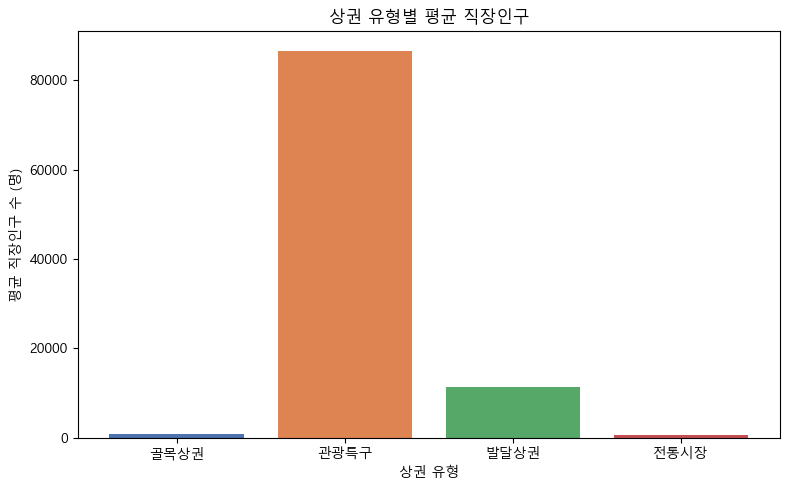

In [4]:
# 상권 유형별 총 직장인구 평균 계산
평균_직장 = df_직장.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_직장['상권_구분_코드_명'], 평균_직장['총_직장_인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 직장인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 직장인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 직장인구
- 관광특구: 약 87,000명으로 압도적 1위
- 발달상권: 약 11,000명으로 2위
- 골목상권/전통시장: 매우 낮음
- 관광특구는 대규모 업무지구와 겹치는 경우가 많아 직장인구 집중

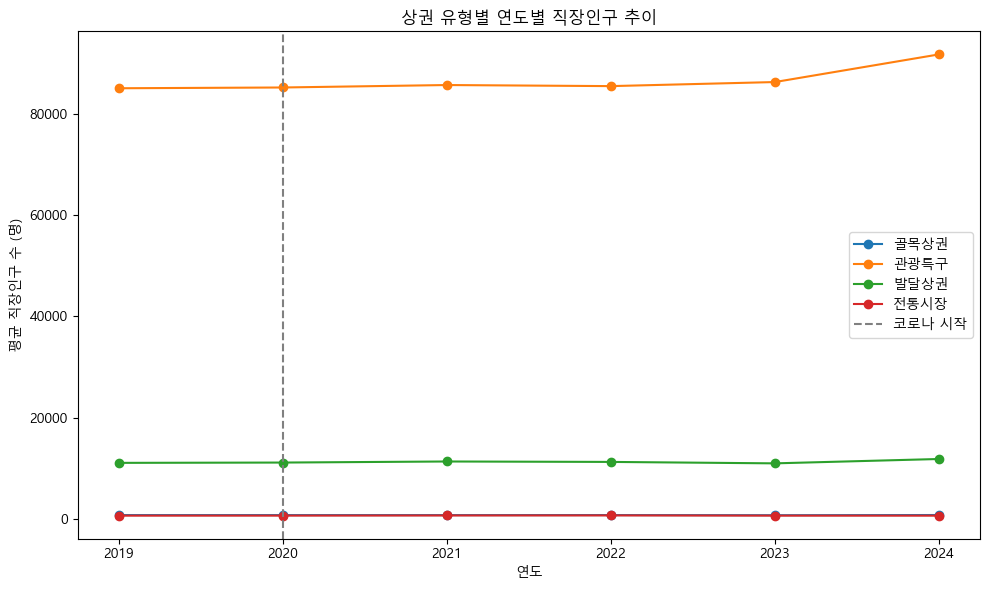

In [5]:
# 연도 컬럼 추가
df_직장['연도'] = df_직장['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 직장인구
연도별 = df_직장.groupby(['연도', '상권_구분_코드_명'])['총_직장_인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별['상권_구분_코드_명'].unique():
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_직장_인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 직장인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 직장인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 직장인구 추이
- 관광특구: 코로나 영향 없이 꾸준히 증가 → 2024년 최고치
- 발달상권: 전체 기간 안정적으로 유지
- 골목상권/전통시장: 직장인구 매우 적음 → 주거/소비 중심 상권
- 전반적으로 직장인구는 코로나 영향을 거의 받지 않음

In [6]:
# 상주인구 데이터 불러오기
df_상주 = pd.read_csv(
    "../data/07_상주인구/서울시 상권분석서비스(상주인구-상권).csv",
    encoding="cp949"
)

# 분석 기간 필터링 (2019~2024)
df_상주 = df_상주[df_상주['기준_년분기_코드'] < 20250]

print("shape:", df_상주.shape)
print("기간:", sorted(df_상주['기준_년분기_코드'].unique()))
print("상권 유형:", df_상주['상권_구분_코드_명'].unique())
print()
print("결측치:")
print(df_상주.isnull().sum())

shape: (34280, 29)
기간: [np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str

결측치:
기준_년분기_코드             0
상권_구분_코드              0
상권_구분_코드_명            0
상권_코드                 0
상권_코드_명               0
총_상주인구_수              0
남성_상주인구_수             0
여성_상주인구_수             0
연령대_10_상주인구_수         0
연령대_20_상주인구_수         0
연령대_30_상주인구_수         0
연령대_40_상주인구_수         0
연령대_50_상주인구_수         0
연령대_60_이상_상주인구_수      0
남성연령대_10_상주인구_수       0
남성연령대_20_상주인구_수       0
남성연령대_30_상주인구_수       0
남성연령대_40_상주인구_수       0
남성연령대_50_상주인구_수       0
남성연령대_60_이상_상주인구_수    0
여성연령대_10_상주인구_수       0
여성연령대_20_상주인구_수       0
여성연령대_30_

## 상주인구 기본 정보
- 행: 34,280개 / 컬럼: 29개
- 기간: 2019Q4 ~ 2024Q4 (직장인구와 달리 2019Q4부터 시작)
- 상권 유형: 4개 
- 결측치: 없음 

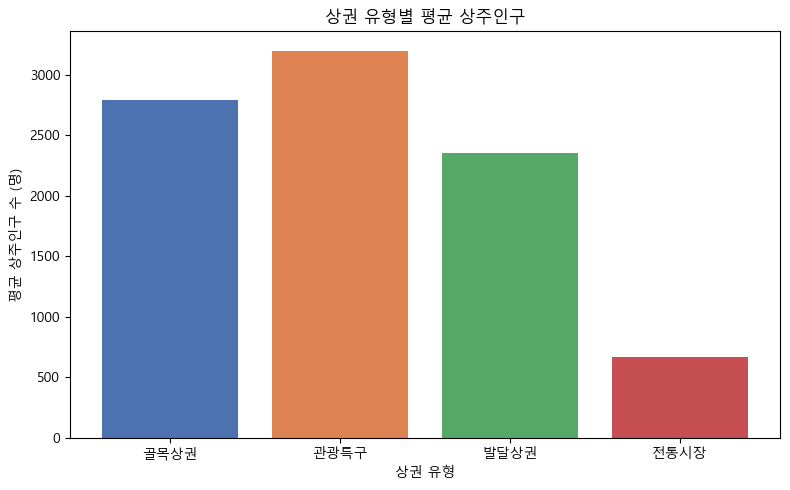

In [7]:
# 상권 유형별 총 상주인구 평균 계산
평균_상주 = df_상주.groupby('상권_구분_코드_명')['총_상주인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_상주['상권_구분_코드_명'], 평균_상주['총_상주인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 상주인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 상주인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 상주인구
- 관광특구: 약 3,200명으로 1위
- 골목상권: 약 2,800명으로 2위 → 주거 밀집 지역에 분포
- 발달상권: 약 2,350명
- 전통시장: 약 670명으로 가장 낮음
- 직장인구와 달리 유형 간 격차가 크지 않음

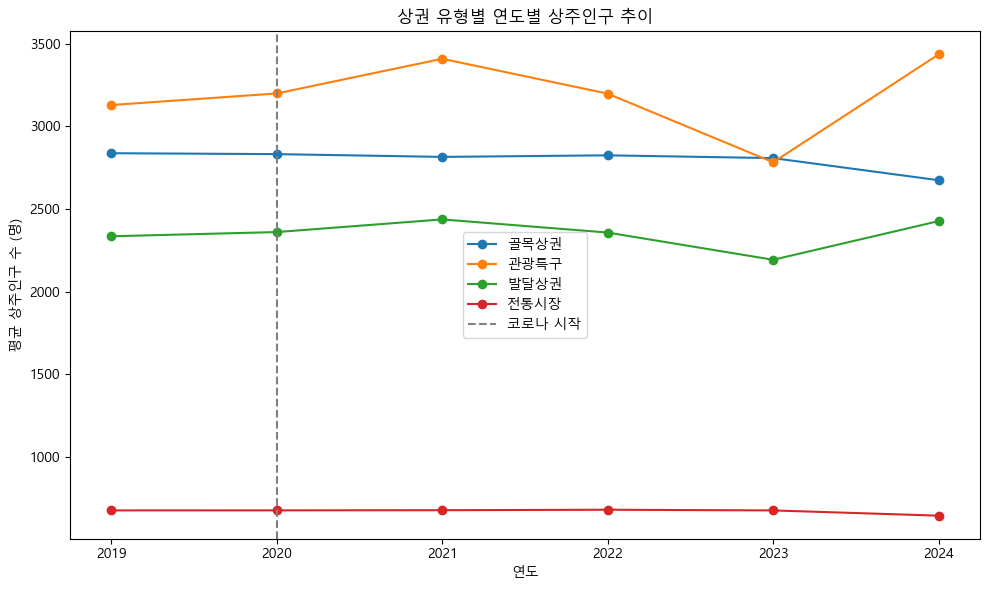

In [8]:
# 연도 컬럼 추가
df_상주['연도'] = df_상주['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 상주인구
연도별_상주 = df_상주.groupby(['연도', '상권_구분_코드_명'])['총_상주인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별_상주['상권_구분_코드_명'].unique():
    df_유형 = 연도별_상주[연도별_상주['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_상주인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상주인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 상주인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상주인구 추이
- 관광특구: 등락 있으나 전반적으로 가장 높음
- 골목상권: 전체 기간 안정적 유지 → 주거 기반 탄탄
- 발달상권: 2023년 하락 후 2024년 회복
- 전통시장: 전체 기간 가장 낮고 변화 거의 없음
- 상주인구는 직장인구와 달리 코로나 영향 거의 없음